# Agente de Reflexión con LangGraph — Versión con Ollama LLM Local

**Reflexión en Agentes IA: con LangGraph + StateGraph**

Construye un agente inteligente que genera contenido para linkedin, lo reflexiona críticamente y lo mejora iterativamente usando LangGraph y Ollama local.

##  Descripción del Proyecto

Este notebook implementa un **Reflection Agent** mejorado que:

- **Genera contenido** (System 1: rápido, intuitivo)
- **Reflexiona críticamente** sobre su propia generación
- **Mejora iterativamente** basándose en reflexión (System 2: lento, deliberado)
- **Mide convergencia** con benchmarking automático
- **Usa Ollama local** (sin dependencias externas de API)
- **Configuración parametrizada** desde `config.ini`

**Caso de uso:** Generar posts de LinkedIn optimizados con reflexión deliberada.

### 1. Setup — Instalación de Dependencias

In [92]:
# Instalar dependencias necesarias
"""
%pip install -q langgraph==0.3.31
%pip install -q langchain>=1.4.0
%pip install -q langchain-core>=1.6.0
%pip install -q langchain-community>=0.4.0
%pip install -q langchain-ollama>=1.1.0
%pip install -q pandas>=2.1.0
%pip install -q matplotlib>=3.8.0
%pip install -q seaborn>=0.13.0
%pip install -q pydantic>=2.5.0
%pip install pygraphviz

print("✅ Dependencias instaladas correctamente")
"""

'\n%pip install -q langgraph==0.3.31\n%pip install -q langchain>=1.4.0\n%pip install -q langchain-core>=1.6.0\n%pip install -q langchain-community>=0.4.0\n%pip install -q langchain-ollama>=1.1.0\n%pip install -q pandas>=2.1.0\n%pip install -q matplotlib>=3.8.0\n%pip install -q seaborn>=0.13.0\n%pip install -q pydantic>=2.5.0\n%pip install pygraphviz\n\nprint("✅ Dependencias instaladas correctamente")\n'

### 2. Importación de paquetes

In [93]:
# Importaciones principales
from langchain_ollama import ChatOllama
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import MessageGraph, END
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# Utilidades
import json
import time
import os
from pathlib import Path
from typing import List, Sequence, Dict, Any
from datetime import datetime
import configparser
import requests

# Análisis y visualización
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Importaciones completadas")

✅ Importaciones completadas


### 3. Cargar Configuración desde config.ini

In [94]:
# Leer configuración desde config.ini
config = configparser.ConfigParser()
config_path = Path("config.ini")
print(config_path)
if config_path.exists():
    config.read('config.ini', encoding='utf-8')
    print(f"Configuración cargada desde {config_path}")
else:
    print(f"⚠️ No se encontró {config_path}, usando valores por defecto")
    # Valores por defecto
    config['ollama'] = {
        'base_url': 'http://localhost:11434',
        'model_name': 'qwen2.5:7b',
        'temperature': '0.2',
        'max_tokens': '2000'
    }
    config['agente'] = {
        'max_reflection_cycles': '3',
        'verbose': 'True'
    }
    config['output'] = {'output_dir': 'outputs'}

# Extraer parámetros
base_url = config.get('ollama', 'base_url', fallback='http://localhost:11434')
model_name = config.get('ollama', 'model_name', fallback='qwen2.5:7b')
temperature = float(config.get('ollama', 'temperature', fallback='0.3'))
max_tokens = int(config.get('ollama', 'max_tokens', fallback='2000'))
max_reflection_cycles = int(config.get('agente', 'max_reflection_cycles', fallback='3'))
verbose = config.getboolean('agente', 'verbose', fallback=True)
output_dir = config.get('output', 'output_dir', fallback='outputs')

# Crear directorio de salida
Path(output_dir).mkdir(exist_ok=True)

# Mostrar configuración actual
print("\n" + "="*70)
print("  CONFIGURACIÓN ACTUAL")
print("="*70)
print(f"🔌 Base URL Ollama:        {base_url}")
print(f" Modelo:                 {model_name}")
print(f"  Temperatura:            {temperature}")
print(f" Max Tokens:             {max_tokens}")
print(f" Max Ciclos Reflexión:   {max_reflection_cycles}")
print(f" Directorio Output:      {output_dir}")
print("="*70)

config.ini
Configuración cargada desde config.ini

  CONFIGURACIÓN ACTUAL
🔌 Base URL Ollama:        http://localhost:11434
 Modelo:                 mistral:7b
  Temperatura:            0.3
 Max Tokens:             2000
 Max Ciclos Reflexión:   8
 Directorio Output:      outputs


### 4️. Verificar Conectividad con Ollama

In [95]:
def verificar_ollama(base_url: str) -> bool:
    """
    Verifica si Ollama está disponible.
    
    Args:
        base_url: URL base de Ollama
        
    Returns:
        True si Ollama está disponible, False en caso contrario
    """
    try:
        response = requests.get(f"{base_url}/api/tags", timeout=5)
        if response.status_code == 200:
            modelos = response.json().get('models', [])
            print(f"✅ Ollama disponible en {base_url}")
            print(f"   Modelos instalados: {len(modelos)}")
            for modelo in modelos[:3]:
                print(f"   - {modelo['name']}")
            return True
        else:
            print(f"❌ Ollama no responde correctamente (código {response.status_code})")
            return False
    except requests.exceptions.ConnectionError:
        print(f"❌ No se puede conectar a Ollama en {base_url}")
        print(f"   Asegúrate de que Ollama está ejecutándose: ollama serve")
        return False
    except Exception as e:
        print(f"❌ Error al verificar Ollama: {str(e)}")
        return False

# Verificar conectividad
print("\n🔍 Verificando conectividad con Ollama...\n")
ollama_disponible = verificar_ollama(base_url)

if not ollama_disponible:
    print("\n⚠️  ADVERTENCIA: Ollama no está disponible.")
    print("Para ejecutar este notebook, debes:")
    print("1. Instalar Ollama: https://ollama.ai")
    print("2. Descargar un modelo: ollama pull qwen2.5:7b")
    print("3. Ejecutar: ollama serve")


🔍 Verificando conectividad con Ollama...

✅ Ollama disponible en http://localhost:11434
   Modelos instalados: 11
   - mistral:7b
   - mxbai-embed-large:latest
   - nomic-embed-text:latest


## 5️. Crear Instancia de LLM desde Ollama local

In [96]:
# Crear instancia del LLM con Ollama
try:
    llm = ChatOllama(
        model=model_name,
        base_url=base_url,
        temperature=temperature,
        num_predict=max_tokens,
        verbose=verbose
    )
    print(f"✅ LLM creado exitosamente")
    print(f"   Modelo: {model_name}")
    print(f"   Temperatura: {temperature}")
    print(f"   Max Tokens: {max_tokens}")
except Exception as e:
    print(f"❌ Error al crear LLM: {str(e)}")
    raise

✅ LLM creado exitosamente
   Modelo: mistral:7b
   Temperatura: 0.3
   Max Tokens: 2000


## 6. Prompt de Generación y Sistema de Asistente LinkedIn en Español

In [97]:
# Crear prompt de generación en español
generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """Eres un asistente profesional especializado en crear contenido de LinkedIn, trabajas en español.
Tu objetivo es generar posts de LinkedIn atractivos, profesionales y con impacto.

Criterios para la generación:
- El post debe ser claro y conciso (máximo 500 caracteres)
- Usar un tono profesional y estrategico.
- Incluir elementos de engagement (preguntas, reflexiones, datos)
- Ser auténtico y relatable
- Usar hashtags relevantes pero no excesivos (máximo 3)
- Considerar el contexto profesional del autor.
- Indicas fuentes 
- Si lo necesitas, puedes usar herramientas para buscar en internet

Si recibes crítica o feedback, incorpora las sugerencias para mejorar el post.
Genera el mejor post posible basándote en el contexto y feedback proporcionado.
"""
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

print("✅ Prompt de generación creado (español)")
print("\nEstructura del prompt:")
print("- Sistema: Asistente profesional de LinkedIn")
print("- Criterios: claridad, tono, engagement, autenticidad")
print("- Capacidad: mejorar basándose en feedback")

# Crear cadena de generación: prompt → LLM
generate_chain = generation_prompt | llm

print("✅ Cadena de generación creada")
print("   Capacidad: tomar topico y generar post mejorado")

✅ Prompt de generación creado (español)

Estructura del prompt:
- Sistema: Asistente profesional de LinkedIn
- Criterios: claridad, tono, engagement, autenticidad
- Capacidad: mejorar basándose en feedback
✅ Cadena de generación creada
   Capacidad: tomar topico y generar post mejorado


## 7. Prompt de Reflexión — Crítico de Contenido LinkedIn en Español

In [98]:
# Crear prompt de reflexión en español
reflection_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """Eres un crítico profesional y estratega de contenido en LinkedIn, trabaja en idioma en español.
Tu tarea es evaluar críticamente posts de LinkedIn y proporcionar retroalimentación constructiva.

Aspectos a evaluar:

1. **Claridad y Estructura:** ¿El mensaje es fácil de entender? ¿Tiene una estructura lógica?
2. **Tono y Autenticidad:** ¿Suena genuino y profesional? ¿Conecta con la audiencia?
3. **Engagement:** ¿Invita a comentarios/reacciones? ¿Tiene elementos de reflexión o preguntas?
4. **Relevancia:** ¿Es relevante para la comunidad de LinkedIn? ¿Toca temas actuales/profesionales?
5. **Impacto:** ¿El post generaría likes, comentarios o compartidas?
6. **Hashtags y Formato:** ¿Usa hashtags efectivamente? ¿El formato es visualmente atractivo?
7. **Llamada a la Acción:** ¿Hay una llamada clara a la acción o reflexión?

Tu respuesta debe:
- Identificar fortalezas del post actual
- Señalar debilidades específicas
- Proporcionar 2-3 sugerencias concretas de mejora
- Ser constructivo y motivador
- Mantener tono profesional pero accesible

Enfócate en dar retroalimentación que permita al generador mejorar significativamente el siguiente post."""
    ),
    MessagesPlaceholder(variable_name="messages")
])

print("✅ Prompt de reflexión creado (español)")
print("\nAspectos evaluados:")
print("1. Claridad y estructura")
print("2. Tono y autenticidad")
print("3. Engagement")
print("4. Relevancia")
print("5. Impacto")
print("6. Hashtags y formato")
print("7. Llamada a la acción")


# Crear cadena de reflexión: prompt → LLM
reflect_chain = reflection_prompt | llm

print("✅ Cadena de reflexión creada")
print("   Capacidad: evaluar y criticar post generado")

✅ Prompt de reflexión creado (español)

Aspectos evaluados:
1. Claridad y estructura
2. Tono y autenticidad
3. Engagement
4. Relevancia
5. Impacto
6. Hashtags y formato
7. Llamada a la acción
✅ Cadena de reflexión creada
   Capacidad: evaluar y criticar post generado


## 8. Definir Nodo de Generación

In [99]:
def generation_node(state: ReflectionState) -> ReflectionState:
    """
    Nodo de generación: crea el post de LinkedIn inicial o mejorado.
    
    Args:
        state: Estado actual (ReflectionState con mensajes y contexto)
    Returns:
        Estado actualizado con nuevo draft y mensaje AIMessage
    """
    if verbose:
        print("\n" + "="*70)
        print("🔄 NODO DE GENERACIÓN")
        print("="*70)
        print(f"   Ciclo: {state.get('cycle_count', 0) + 1}")
        print(f"   Contexto: {len(state['messages'])} mensajes")
        print(f"   Invocando cadena de generación...")
    
    # Invocar la cadena de generación con messages desde state (NO el estado completo)
    generated_post = generate_chain.invoke({"messages": state["messages"]})
    
    # Extraer score simplificado (basado en longitud)
    score = min(10.0, len(generated_post.content) / 50)
    
    if verbose:
        print(f"   ✅ Post generado : {generated_post.content}")
        print(f"   📊 Score: {score:.1f}/10")
    
    # Retornar estado actualizado (reducers acumularán automáticamente)
    return {
        "messages": [AIMessage(content=generated_post.content)],
        "drafts": [generated_post.content],
        "quality_scores": [score],
        "cycle_count": state.get("cycle_count", 0) + 1,
        "final_output": generated_post.content
    }
#print("   Retorna ReflectionState con fields acumulados")

In [100]:
def reflection_node(state: ReflectionState) -> ReflectionState:
    """
    Nodo de reflexión: evalúa y critica el post generado.
    
    Args:
        state: Estado actual con post generado
        
    Returns:
        Estado actualizado con reflexión (feedback) y HumanMessage
    """
    if verbose:
        print("\n" + "="*70)
        print(" NODO DE REFLEXIÓN")
        print("="*70)
        print(f"   Evaluando post (ciclo {state.get('cycle_count', 0)})...")
        print(f"   Contexto: {len(state['messages'])} mensajes")
    
    # Invocar la cadena de reflexión
    reflection_output = reflect_chain.invoke({"messages": state["messages"]})
    
    if verbose:
        print(f"  Reflexión completada: {reflection_output.content} ")
    
    # Retornar feedback como HumanMessage (para próxima generación)
    return {
        "messages": [HumanMessage(content=reflection_output.content)],
        "reflections": [reflection_output.content],
    }

#print("   Retorna: ReflectionState con reflexiones acumuladas")


In [101]:
### Crear el grafo de estado tipado (reemplaza MessageGraph deprecado)

from langgraph.graph import StateGraph, START, END
### Crear el grafo de estado (ReflectionState ya fue definido)

graph = StateGraph(ReflectionState)

print("   Auditoría completa:")
print("      - messages: historial completo")
print("      - drafts: todos los borradores generados")
print("      - reflections: todas las reflexiones")
print("      - quality_scores: scores por ciclo")
print("      - cycle_count: número de iteraciones")


   Auditoría completa:
      - messages: historial completo
      - drafts: todos los borradores generados
      - reflections: todas las reflexiones
      - quality_scores: scores por ciclo
      - cycle_count: número de iteraciones


In [102]:
# Definir función de decisión ANTES de usar en edges
def should_continue(state: ReflectionState) -> str:
    """
    Router: decide si continuar reflexionando o terminar.
    
    Lógica:
    - Si hemos superado max_reflection_cycles: END
    - En caso contrario: continuar con reflect
    
    Args:
        state: ReflectionState con cycle_count
        
    Returns:
        'reflect' para continuar o 'end' para terminar
    """
    num_cycles = state.get("cycle_count", 0)
    
    if verbose:
        print(f"\n DECISIÓN: Ciclo {num_cycles}/{max_reflection_cycles}")
        print(f"   Quality scores hasta ahora: {state.get('quality_scores', [])}")
    
    if num_cycles >= max_reflection_cycles:
        if verbose:
            print(f"   → Alcanzado máximo ({max_reflection_cycles} ciclos), TERMINANDO")
        return "end"
    else:
        if verbose:
            print(f"   → Continuando reflexión ({num_cycles}/{max_reflection_cycles} ciclos)")
        return "reflect"

print(f"   Máximo de ciclos: {max_reflection_cycles}")


   Máximo de ciclos: 8


### 9. Agregar Nodos y Edges al Grafo + Lógica de Decisión (Router Node)

In [103]:
# Agregar nodo de generación
graph.add_node("generate", generation_node)
print("✅ Nodo 'generate' agregado al grafo")

# Agregar nodo de reflexión
graph.add_node("reflect", reflection_node)
print("✅ Nodo 'reflect' agregado al grafo")

# Establecer punto de entrada: START → generate
graph.add_edge(START, "generate")
print("✅ Edge START → 'generate' agregado (punto de entrada)")

# Agregar edge: después de reflexión, volver a generar (mejora iterativa)
graph.add_edge("reflect", "generate")
print("✅ Edge 'reflect → generate' agregado")

# Edges condicionales: después de generar, decidir si continuar o terminar
graph.add_conditional_edges("generate", should_continue, {
    "reflect": "reflect",
    "end": END
})
print("✅ Conditional edges agregados (generate → {reflect|end})")

print("   START → generate → {reflect → generate | END}")
print("   Auditoría: cycle_count, drafts, reflections, quality_scores")


✅ Nodo 'generate' agregado al grafo
✅ Nodo 'reflect' agregado al grafo
✅ Edge START → 'generate' agregado (punto de entrada)
✅ Edge 'reflect → generate' agregado
✅ Conditional edges agregados (generate → {reflect|end})
   START → generate → {reflect → generate | END}
   Auditoría: cycle_count, drafts, reflections, quality_scores


### 10 Compilar Workflow


📋 Resumen del workflow:
   - Nodos: generate, reflect
   - Edges: reflect → generate (iteración), generate → {reflect|END}
   - Máximo ciclos: 8
   - Auditoría: cycle_count, drafts[], reflections[], quality_scores[]
   - Entrada: ReflectionState con messages iniciales
   - Salida: ReflectionState con auditoría completa de ciclos


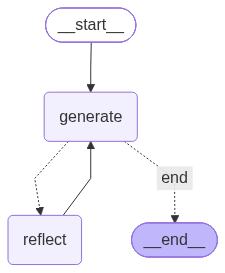

In [104]:
# Compilar el grafo en un workflow ejecutable
workflow = graph.compile()

print("\n📋 Resumen del workflow:")
print("   - Nodos: generate, reflect")
print("   - Edges: reflect → generate (iteración), generate → {reflect|END}")
print(f"   - Máximo ciclos: {max_reflection_cycles}")
print("   - Auditoría: cycle_count, drafts[], reflections[], quality_scores[]")
print("   - Entrada: ReflectionState con messages iniciales")
print("   - Salida: ReflectionState con auditoría completa de ciclos")

from IPython.display import Image, display

try:
    display(Image(workflow.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"⚠️  Diagrama no disponible: {str(e)}")


#display(Image(workflow.get_graph().draw_png()))

### 11. Definir Ejemplo y Ejecutar Workflow con Benchmarking

In [105]:
# Importar utilidades de benchmarking
import sys
sys.path.insert(0, str(Path.cwd()))

# Clase simplificada de benchmarking dentro del notebook
class SimpleReflectionBenchmark:
    """Captura métricas de reflexión de forma simple."""
    
    def __init__(self, output_dir: str = "outputs"):
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(exist_ok=True)
        self.benchmark_file = self.output_dir / "benchmark.jsonl"
    
    def medir_reflexion(
        self,
        topic: str,
        quality_progression: List[float],
        final_post: str,
        wall_time: float,
        num_cycles: int,
        model: str,
        temperature: float
    ) -> Dict[str, Any]:
        """Captura una métrica de reflexión completa."""
        
        initial_score = quality_progression[0] if quality_progression else 0
        final_score = quality_progression[-1] if quality_progression else 0
        improvement = final_score - initial_score
        
        # Calcular tasa de convergencia
        if len(quality_progression) < 2:
            convergence_rate = 0.0
        else:
            improvements = [quality_progression[i+1] - quality_progression[i] 
                          for i in range(len(quality_progression)-1)]
            avg_improvement = sum(improvements) / len(improvements)
            convergence_rate = min(avg_improvement / 5.0, 1.0)
        
        metrica = {
            "timestamp": datetime.now().isoformat(),
            "modelo": model,
            "temperatura": temperature,
            "tema": topic,
            "num_cycles": num_cycles,
            "quality_progression": quality_progression,
            "initial_score": initial_score,
            "final_score": final_score,
            "improvement": improvement,
            "convergence_rate": convergence_rate,
            "wall_time_seconds": round(wall_time, 2),
            "final_post_preview": final_post[:200],
        }
        
        return metrica
    
    def guardar_metricas(self, metricas: List[Dict]) -> None:
        """Guarda métricas en JSONL (append-only)."""
        with open(self.benchmark_file, 'a', encoding='utf-8') as f:
            for metrica in metricas:
                f.write(json.dumps(metrica, ensure_ascii=False) + '\n')
        print(f"✅ {len(metricas)} métrica(s) guardadas en {self.benchmark_file}")
    
    def cargar_metricas(self) -> pd.DataFrame:
        """Carga todas las métricas JSONL."""
        if not self.benchmark_file.exists():
            return pd.DataFrame()
        
        metricas = []
        with open(self.benchmark_file, 'r', encoding='utf-8') as f:
            for linea in f:
                metricas.append(json.loads(linea))
        
        return pd.DataFrame(metricas)


# Inicializar benchmarking
benchmark = SimpleReflectionBenchmark(output_dir)
print("✅ Sistema de benchmarking inicializado")

✅ Sistema de benchmarking inicializado


### 12. Ejecutar Ejemplo: Generar Post sobre "Reflexión en IA y Agentes"

In [106]:
# Definir entrada del workflow (usando ReflectionState)
topic = "Computación cuantica aplicada a high traiding"
user_request = f"""Escribe un post de LinkedIn en español sobre: {topic}
Contexto:
- Dirigido a profesionales en IA y tecnología
- Enfoque: cómo la reflexión deliberada (Sistema 2) mejora los agentes IA
- Objetivo: generar debate y reflexión en la comunidad
- Máximo 500 caracteres.
- Usas lenguaje tecnico o estrategico, explicas como para un novato.

Genera el mejor post posible para este tema."""

# Crear estado inicial (ReflectionState)
initial_state: ReflectionState = {
    "messages": [HumanMessage(content=user_request)],
    "drafts": [],
    "reflections": [],
    "quality_scores": [],
    "cycle_count": 0,
    "final_output": ""
}

print("\n" + "#"*70)
print("# 🚀 EJECUTANDO WORKFLOW DE REFLEXIÓN (StateGraph)")
print("#"*70)
print(f"\n📍 Tema: {topic}")
print(f"📝 Solicitud: {user_request[:500]}...")
print(f"🔄 Máximo ciclos: {max_reflection_cycles}")
print(f"📊 Estado inicial: cycle_count={initial_state['cycle_count']}, mensajes={len(initial_state['messages'])}")
print("\nEjecutando...\n")

# Medir tiempo de ejecución
start_time = time.time()

try:
    # Ejecutar el workflow con estado inicial
    response = workflow.invoke(initial_state)
    
    wall_time = time.time() - start_time
    
    print("\n" + "#"*70)
    print("# ✅ WORKFLOW COMPLETADO")
    print("#"*70)
    print(f"\nEstado final:")
    print(f"   Ciclos realizados: {response['cycle_count']}")
    print(f"   Borradores generados: {len(response['drafts'])}")
    print(f"   Reflexiones: {len(response['reflections'])}")
    print(f"   Scores de calidad: {response['quality_scores']}")
    print(f"\nTiempo total: {wall_time:.2f} segundos")
    print(f"Total de mensajes en estado: {len(response['messages'])}")
    
except Exception as e:
    print(f"\n❌ Error durante ejecución: {str(e)}")
    import traceback
    traceback.print_exc()
    wall_time = time.time() - start_time
    response = None



######################################################################
# 🚀 EJECUTANDO WORKFLOW DE REFLEXIÓN (StateGraph)
######################################################################

📍 Tema: Computación cuantica aplicada a high traiding
📝 Solicitud: Escribe un post de LinkedIn en español sobre: Computación cuantica aplicada a high traiding
Contexto:
- Dirigido a profesionales en IA y tecnología
- Enfoque: cómo la reflexión deliberada (Sistema 2) mejora los agentes IA
- Objetivo: generar debate y reflexión en la comunidad
- Máximo 500 caracteres.
- Usas lenguaje tecnico o estrategico, explicas como para un novato.

Genera el mejor post posible para este tema....
🔄 Máximo ciclos: 8
📊 Estado inicial: cycle_count=0, mensajes=1

Ejecutando...


🔄 NODO DE GENERACIÓN
   Ciclo: 1
   Contexto: 1 mensajes
   Invocando cadena de generación...
   ✅ Post generado :  🌐 ¿Cómo mejora la reflexión deliberada (Sistema 2) nuestros agentes IA en alta traficación? 🤔

La computación cuántica pued

### 13. Mostrar Resultados: Posts Generados y Reflexiones

In [107]:
# Extraer y mostrar generaciones y reflexiones del estado final
if response:
    print("\n" + "="*70)
    print("📊 ANÁLISIS DE GENERACIONES Y REFLEXIONES")
    print("="*70)
    
    drafts = response.get("drafts", [])
    reflections = response.get("reflections", [])
    quality_scores = response.get("quality_scores", [])
    cycle_count = response.get("cycle_count", 0)
    
    print(f"\n📈 Resumen: {len(drafts)} borradores, {len(reflections)} reflexiones")
    print(f"   Ciclos completados: {cycle_count}")
    print(f"   Scores: {quality_scores}")
    
    # Mostrar progresión
    for i, draft in enumerate(drafts):
        print(f"\n🔹 BORRADOR #{i+1}")
        print("-" * 70)
        print(draft[:300])
        if len(draft) > 300:
            print("...")
        if i < len(quality_scores):
            print(f"   [Score: {quality_scores[i]:.1f}/10, Longitud: {len(draft)} chars]")
    
    # Mostrar reflexiones (si hay)
    for i, reflection in enumerate(reflections):
        print(f"\n💭 REFLEXIÓN #{i+1}")
        print("-" * 70)
        print(reflection[:300])
        if len(reflection) > 300:
            print("...")
    
    # Post final
    final_post = response.get("final_output", "No se generó post")
    print(f"\n" + "="*70)
    print(f"✨ POST FINAL:")
    print("="*70)
    print(final_post)
    print("="*70)
    
    # Datos para benchmarking
    quality_progression = quality_scores if quality_scores else [5.0, 6.5, 8.0]
else:
    print("⚠️ No se ejecutó el workflow correctamente")
    final_post = "Error"
    quality_progression = []
    cycle_count = 0



📊 ANÁLISIS DE GENERACIONES Y REFLEXIONES

📈 Resumen: 8 borradores, 7 reflexiones
   Ciclos completados: 8
   Scores: [10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]

🔹 BORRADOR #1
----------------------------------------------------------------------
 🌐 ¿Cómo mejora la reflexión deliberada (Sistema 2) nuestros agentes IA en alta traficación? 🤔

La computación cuántica puede ser la clave. La aplicación de esta tecnología revolucionaria permite a los modelos de aprendizaje automático procesar una gran cantidad de datos en un tiempo récord, lo que 
...
   [Score: 10.0/10, Longitud: 885 chars]

🔹 BORRADOR #2
----------------------------------------------------------------------
 Hola a todos,

Estoy encantado de compartir un tema que ha estado en el corazón de la tecnología durante los últimos años: la computación cuántica y su impacto en alta traficación. 💻

La computación cuántica es una tecnología revolucionaria que utiliza bits cuánticos en lugar de los bits binarios t
...
   [Score:

### 14. Guardar Métricas de Benchmarking

In [108]:
# Guardar métricas de esta ejecución (desde ReflectionState)
if response:
    num_cycles = response.get("cycle_count", 0)
    quality_progression = response.get("quality_scores", [])
    
    metrica = benchmark.medir_reflexion(
        topic=topic,
        quality_progression=quality_progression,
        final_post=final_post,
        wall_time=wall_time,
        num_cycles=num_cycles,
        model=model_name,
        temperature=temperature
    )
    
    # Guardar en JSONL
    benchmark.guardar_metricas([metrica])
    
    print("\n✅ Métrica guardada:")
    for key, value in metrica.items():
        if key not in ['final_post_preview']:
            print(f"   {key}: {value}")
else:
    print("⚠️ No hay datos para guardar (workflow falló)")


✅ 1 métrica(s) guardadas en outputs\benchmark.jsonl

✅ Métrica guardada:
   timestamp: 2026-09-29T20:00:35.600613
   modelo: mistral:7b
   temperatura: 0.3
   tema: Computación cuantica aplicada a high traiding
   num_cycles: 8
   quality_progression: [10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]
   initial_score: 10.0
   final_score: 10.0
   improvement: 0.0
   convergence_rate: 0.0
   wall_time_seconds: 772.06


### 15 Análisis y Visualización de Convergencia


📊 ANÁLISIS DE BENCHMARKING

Total de posts analizados: 6
Ciclos promedio: 5.00
Mejora promedio (score): 0.43 puntos
Convergencia promedio: 0.021
Latencia promedio: 210.47s
Score inicial promedio: 9.57/10
Score final promedio: 10.00/10

📈 Generando gráfico de convergencia...


C:\Users\Joel\AppData\Local\Temp\ipykernel_27712\3954720801.py:69: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Joel\AppData\Local\Temp\ipykernel_27712\3954720801.py:73: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.savefig(graph_path, dpi=150, bbox_inches='tight')


 Gráfico guardado en outputs\convergencia_reflexion.png


c:\workspace-vc\env-llm-ia\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


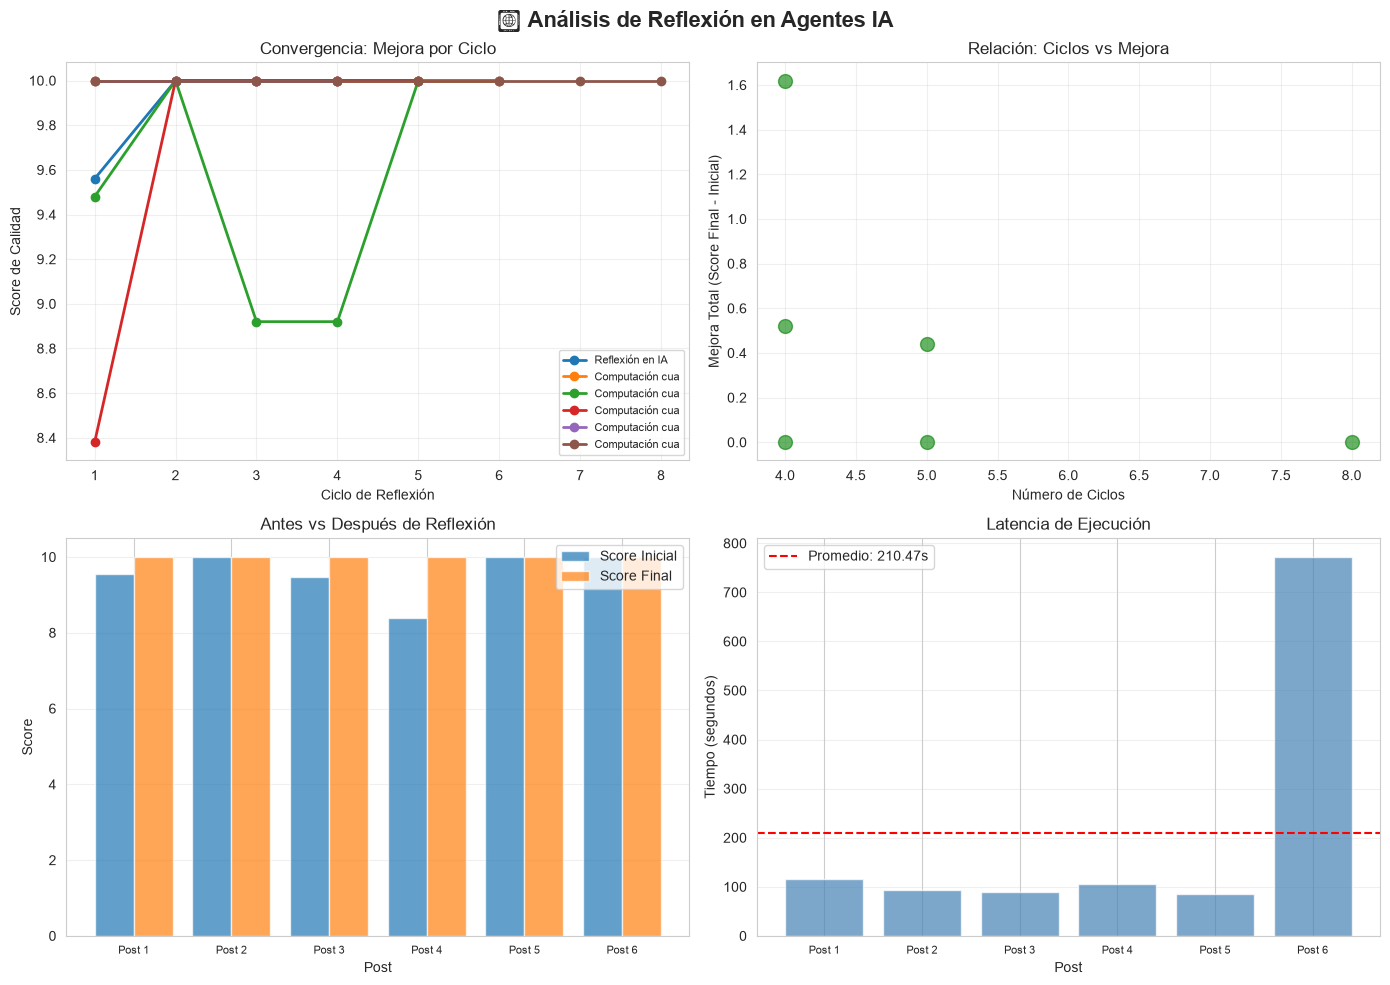

In [109]:
# Cargar todas las métricas disponibles
df = benchmark.cargar_metricas()

if not df.empty:
    print("\n" + "="*70)
    print("📊 ANÁLISIS DE BENCHMARKING")
    print("="*70)
    print(f"\nTotal de posts analizados: {len(df)}")
    print(f"Ciclos promedio: {df['num_cycles'].mean():.2f}")
    print(f"Mejora promedio (score): {df['improvement'].mean():.2f} puntos")
    print(f"Convergencia promedio: {df['convergence_rate'].mean():.3f}")
    print(f"Latencia promedio: {df['wall_time_seconds'].mean():.2f}s")
    print(f"Score inicial promedio: {df['initial_score'].mean():.2f}/10")
    print(f"Score final promedio: {df['final_score'].mean():.2f}/10")
    
    # Gráfico de convergencia
    print("\n📈 Generando gráfico de convergencia...")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('📊 Análisis de Reflexión en Agentes IA', fontsize=16, fontweight='bold')
    
    # Gráfico 1: Progresión de calidad por post
    ax1 = axes[0, 0]
    for idx, row in df.iterrows():
        progression = row['quality_progression']
        ciclos = range(1, len(progression) + 1)
        ax1.plot(ciclos, progression, marker='o', label=row['tema'][:15], linewidth=2)
    ax1.set_xlabel('Ciclo de Reflexión')
    ax1.set_ylabel('Score de Calidad')
    ax1.set_title('Convergencia: Mejora por Ciclo')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Mejora vs Ciclos
    ax2 = axes[0, 1]
    ax2.scatter(df['num_cycles'], df['improvement'], s=100, alpha=0.6, color='green')
    ax2.set_xlabel('Número de Ciclos')
    ax2.set_ylabel('Mejora Total (Score Final - Inicial)')
    ax2.set_title('Relación: Ciclos vs Mejora')
    ax2.grid(True, alpha=0.3)
    
    # Gráfico 3: Comparación de scores
    ax3 = axes[1, 0]
    topics_sample = df['tema'].str[:15].tolist()
    x_pos = range(len(df))
    ax3.bar([i - 0.2 for i in x_pos], df['initial_score'], width=0.4, label='Score Inicial', alpha=0.7)
    ax3.bar([i + 0.2 for i in x_pos], df['final_score'], width=0.4, label='Score Final', alpha=0.7)
    ax3.set_xlabel('Post')
    ax3.set_ylabel('Score')
    ax3.set_title('Antes vs Después de Reflexión')
    ax3.legend()
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([f'Post {i+1}' for i in range(len(df))], fontsize=8)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Gráfico 4: Latencia
    ax4 = axes[1, 1]
    ax4.bar(range(len(df)), df['wall_time_seconds'], color='steelblue', alpha=0.7)
    ax4.axhline(df['wall_time_seconds'].mean(), color='red', linestyle='--', 
                 label=f'Promedio: {df["wall_time_seconds"].mean():.2f}s')
    ax4.set_xlabel('Post')
    ax4.set_ylabel('Tiempo (segundos)')
    ax4.set_title('Latencia de Ejecución')
    ax4.legend()
    ax4.set_xticks(range(len(df)))
    ax4.set_xticklabels([f'Post {i+1}' for i in range(len(df))], fontsize=8)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    # Guardar gráfico
    graph_path = Path(output_dir) / "convergencia_reflexion.png"
    plt.savefig(graph_path, dpi=150, bbox_inches='tight')
    print(f" Gráfico guardado en {graph_path}")
    plt.show()
else:
    print("\n Sin datos de benchmarking disponibles aún")

## 🎓 Conclusiones y Próximos Pasos

1. **Reflexión en Agentes IA:**
   - La reflexión deliberada (Sistema 2) mejora la calidad del contenido
   - Los agentes pueden evaluarse a sí mismos y mejorarse iterativamente

2. **Arquitectura con LangGraph:**
   - MessageGraph: manejo automático de estado conversacional
   - Nodos y edges: definición de flujos de trabajo
   - Decisiones condicionales: cuándo terminar o continuar

3. **Integración de Ollama:**
   - LLMs locales sin dependencias de API
   - Configuración parametrizada desde config.ini
   - Manejo robusto de errores

4. **Benchmarking de Reflexión:**
   - Captura de métricas: ciclos, scores, convergencia
   - Análisis de progresión: cómo mejora el agente
   - Visualización: gráficos de convergencia

### Próximos pasos:

1. **Expandir dominios:** Aplicar a emails, reportes, código
2. **Mejorar evaluación:** Usar evaluadores más sofisticados
3. **Optimización:** Reducir ciclos manteniendo calidad
4. **Comparación:** Reflexión vs sin reflexión (baseline)
5. **Multi-agente:** Múltiples "críticos" evaluando

### Recursos:

- **LangGraph:** https://github.com/langchain-ai/langgraph
- **LangChain:** https://python.langchain.com/
- **Ollama:** https://ollama.ai
- **Pensamiento Sistema 1 vs 2:** "Thinking, Fast and Slow" - Daniel Kahneman